# C1 — Tournées de livraison vertes (Electric VRP)
**EPITA SCIA 2026 — Programmation par Contraintes**

## Objectifs
1. Modéliser l'EVRP avec **CP-SAT** (`AddCircuit`, batterie cumulative, fenêtres horaires)
2. Implémenter **ALNS** (Adaptive Large Neighbourhood Search) pour comparaison
3. Évaluer sur des instances **Schneider-like** (paramètres calés sur Schneider et al., 2014)
4. Analyser : qualité de solution, profil batterie, scalabilité

## Références
- Schneider, M., Stenger, A., & Goeke, D. (2014). *The Electric Vehicle-Routing Problem with Time Windows and Recharging Stations.* Transportation Science, 48(4), 500–520.
- Felipe, Á., et al. (2014). *A Heuristic Approach for the Green Vehicle Routing Problem.* Expert Systems with Applications, 41(14), 6424–6437.
- Ropke, S., & Pisinger, D. (2006). *An Adaptive Large Neighborhood Search Heuristic.* Transportation Science, 40(4), 455–472.

In [8]:
import sys, os, time
import importlib
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import src.instance as _src_instance
importlib.reload(_src_instance)
from src.instance import EVRPInstance, DEPOT, CUSTOMER, STATION, load_benchmark, evrptw_instances_dir
from src.cpsat_solver import solve_evrp
from src.alns import solve_alns, greedy_initial
from src.visualization import plot_instance, plot_routes, plot_battery_profile, plot_comparison
print('Imports OK (src.instance rechargé)')


Imports OK (src.instance rechargé)


---
## 1. Formalisation du problème EVRP

### 1.1 Le problème

On a une flotte de camions électriques qui partent d'un dépôt, livrent des clients, et rentrent. La différence avec un VRP classique : les camions ont une **batterie** qui se vide en roulant, et peuvent s'arrêter à des **bornes de recharge**.

Le graphe $G=(V,A)$ contient trois types de nœuds :
- `0` = le dépôt (départ/retour)
- $C$ = les clients (à livrer obligatoirement)
- $S$ = les stations de recharge (optionnelles)

| Contrainte | CVRP classique | EVRP |
|-----------|---------------|------|
| Capacité véhicule | ✓ | ✓ |
| Fenêtres horaires | optionnel | ✓ |
| Autonomie batterie | ✗ | ✓ |
| Bornes de recharge | ✗ | ✓ |
| Consommation variable (charge, pente) | ✗ | ✓ |

### 1.2 La formule d'énergie

$$e_{ij}(q) = \underbrace{r \cdot d_{ij} \cdot (1 + \alpha \cdot \text{slope}_{ij})}_{\text{base\_e}_{ij}} \cdot \left(1 + \lambda \cdot \frac{q}{Q}\right)$$

Elle se lit en deux parties :

**`base_e` — l'énergie à vide :**
- $r$ : taux de consommation de base (ex. 0,2 kWh/km)
- $d_{ij}$ : distance de l'arc
- $(1 + \alpha \cdot \text{slope}_{ij})$ : correction de pente — montée = plus d'énergie, descente = moins

**Facteur de charge :**
- $(1 + \lambda \cdot q/Q)$ : plus le camion est chargé, plus il consomme
- $q$ = charge embarquée, $Q$ = capacité max, $\lambda$ = sensibilité (ex. 0,1 → +10% à pleine charge)

### 1.3 Variables du modèle CP-SAT

| Variable | Domaine | Signification |
|----------|---------|---------------|
| `arc[v][i][j]` | {0, 1} | Le véhicule $v$ emprunte-t-il l'arc $i \to j$ ? |
| `load[v][i]` | $[0, Q]$ | Charge embarquée par $v$ quand il quitte $i$ |
| `bat_arrive[v][i]` | $[0, B]$ | Batterie **avant** recharge à $i$ |
| `bat_depart[v][i]` | $[0, B]$ | Batterie **après** recharge à $i$ |
| `bonus[v][i][j]` | $[0, \lfloor\text{base\_e}\cdot\lambda\rfloor]$ | Surcoût batterie dû à la charge transportée |
| `time[v][i]` | $[0, T]$ | Heure d'arrivée du véhicule $v$ en $i$ |

> **Pourquoi deux variables batterie ?** Parce qu'à une borne de recharge, la batterie change entre l'arrivée et le départ. Sans cette séparation, une seule variable ne pourrait pas représenter les deux états.

### 1.4 Contraintes

**Circuit hamiltonien — `AddCircuit`**

Chaque véhicule forme un cycle fermé (dépôt → clients → dépôt). L'astuce des **self-loops** : `arc[v][(i,i)] = 1` signifie que le véhicule $v$ *saute* le nœud $i$. Si un client est sauté par $K-1$ véhicules, exactement 1 le visite :
$$\sum_v \text{arc}[v][(i,i)] = K - 1 \quad \forall i \in C$$

**Propagation de charge**

$$\text{arc}[v][i][j]=1 \implies \text{load}[v][j] = \text{load}[v][i] + \text{dem}[j] \quad \forall j \in C$$

La charge augmente à chaque client livré. La contrainte n'est active que si l'arc est emprunté (`only_enforce_if`).

**Recharge complète aux stations**

$$\text{bat\_depart}[v][s] = B \quad \forall s \in S$$

Modèle simplifié : on repart toujours avec la batterie pleine depuis une borne.

**Énergie variable — le point technique clé**

Le problème : `load[v][i]` est une *variable* CP-SAT, pas un nombre fixe. On ne peut pas calculer l'énergie à l'avance. La solution : poser
$$\text{bonus}[v][i][j] = \left\lfloor C_{ij} \cdot \frac{\text{load}[v][i]}{Q} \right\rfloor, \quad C_{ij} = \lfloor \text{base\_e}_{ij} \cdot \lambda \rfloor$$
où $C_{ij}$ est une **constante** précalculée par arc. Le terme $C_{ij} \cdot \text{load}[v][i]$ est alors **linéaire** en la variable CP-SAT, et la division entière par $Q$ est encodée directement :
```python
model.add_division_equality(bonus, C_ij * load[v][i], Q)
```
Quand $\lambda = 0$ (instances Schneider) ou $C_{ij} = 0$ (très courts arcs), aucune variable `bonus` n'est créée.

**Propagation batterie**

$$\text{arc}[v][i][j]=1 \implies \text{bat\_arrive}[v][j] = \text{bat\_depart}[v][i] - \text{base\_e}_{ij} - \text{bonus}[v][i][j]$$
$$\text{bat\_arrive}[v][j] \geq 0$$

En roulant de $i$ vers $j$, la batterie perd `base_e + bonus`. Elle ne peut jamais être négative.

**Fenêtres horaires**

$$a_i \leq \text{time}[v][i] \leq b_i \quad \forall v, i \in C \text{ visité par } v$$

Chaque client a une plage horaire acceptable. La contrainte est conditionnelle : elle ne s'applique que si le véhicule visite réellement le client.

### 1.5 Objectif

$$\min \sum_v \sum_{i \neq j} d_{ij} \cdot \text{arc}[v][i][j]$$

On minimise la **distance totale** parcourue — proxy des émissions CO₂ et de la consommation énergétique.

---
## 2. Instance de démonstration

Instance **réelle** (`data/evrptw_instances/c101C5.txt`). Le fichier ne fixe pas la taille de flotte : le parseur utilise $K=\lceil n/5\rceil$, ce qui donne **un seul** véhicule pour 5 clients — très dur pour CP-SAT avec fenêtres + batterie.

Pour les sections suivantes on utilise **`inst`** avec **au moins 3 véhicules** (même graphe), ce qui reste réaliste et permet au solveur de terminer.


Fichier      : data/evrptw_instances/c101C5.txt
Flotte       : 3 véhicule(s) (fichier seul → 1)
Nœuds        : 9  (1 dépôt + 5 clients + 3 stations)
Capacité     : 200 unités  |  Demande totale : 90
Batterie     : 77.75 kWh
Consommation : 1.00 kWh/km (charge vide)


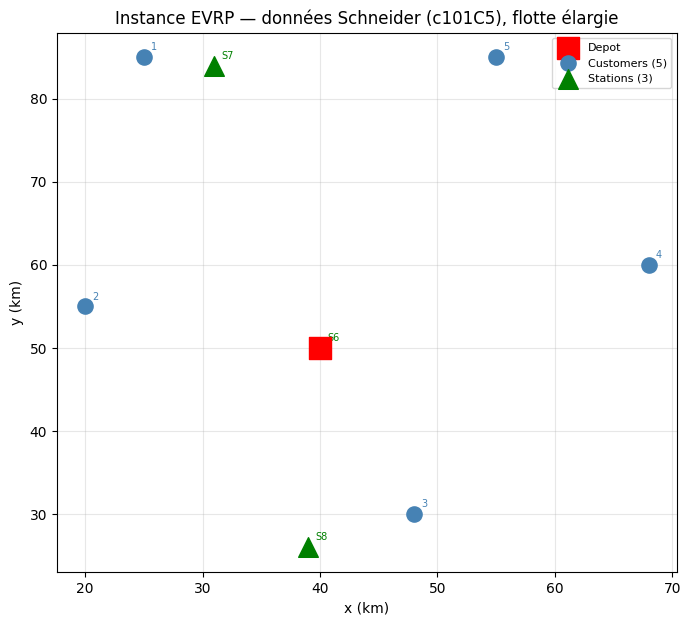

In [9]:
_base = load_benchmark('c101C5')
inst = _base.with_n_vehicles(max(_base.n_vehicles, 3))
print(f'Fichier      : data/evrptw_instances/c101C5.txt')
print(f'Flotte       : {inst.n_vehicles} véhicule(s) (fichier seul → {_base.n_vehicles})')
print(f'Nœuds        : {inst.n_nodes}  (1 dépôt + {inst.n_customers} clients + {inst.n_stations} stations)')
print(f'Capacité     : {inst.vehicle_capacity} unités  |  Demande totale : {inst.total_demand()}')
print(f'Batterie     : {inst.battery_capacity / 100:.2f} kWh')
print(f'Consommation : {inst.consumption_rate / 10:.2f} kWh/km (charge vide)')
fig, ax = plt.subplots(figsize=(8, 7))
plot_instance(inst, ax=ax, title='Instance EVRP — données Schneider (c101C5), flotte élargie')
plt.show()


---
## 3a. Résolution CP-SAT

On autorise jusqu’à **120 s**, d’abord **avec** fenêtres temps ; si aucune solution, nouvel essai **sans** fenêtres (même batterie et capacité).


In [10]:
CP_SAT_SEC = 120
print('Résolution CP-SAT...')
t0 = time.time()
sol_cpsat = solve_evrp(inst, time_limit_s=CP_SAT_SEC, use_time_windows=True)
t_cpsat = time.time() - t0
print(sol_cpsat)
print(f'Temps : {t_cpsat:.2f} s')

if not sol_cpsat.is_feasible():
    print('\nPas de solution avec fenêtres temps — nouvel essai sans contraintes de fenêtres (même horizon).')
    t0 = time.time()
    sol_cpsat = solve_evrp(inst, time_limit_s=CP_SAT_SEC, use_time_windows=False)
    t_cpsat = time.time() - t0
    print(sol_cpsat)
    print(f'Temps : {t_cpsat:.2f} s')


Résolution CP-SAT...
Status     : OPTIMAL
Total dist : 234.70 km
Wall time  : 0.06 s
Stations   : [6, 7, 8] (3 open)
  V0: depot → n3 → n4 → n6 → depot
  V1: depot → n2 → n6 → depot
  V2: depot → n6 → n1 → n5 → depot
Temps : 0.06 s


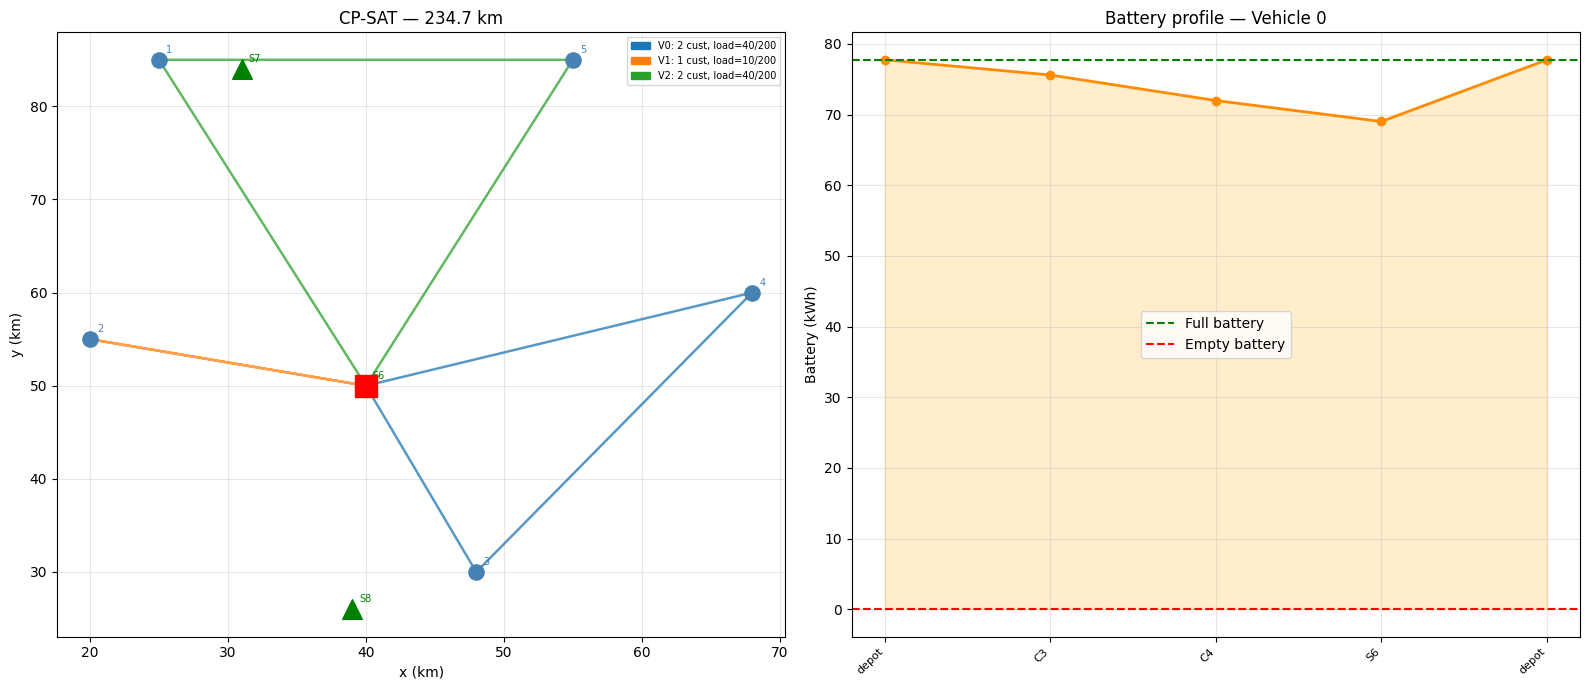

In [11]:
if sol_cpsat.is_feasible():
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    plot_routes(sol_cpsat.routes, inst, ax=axes[0], title='CP-SAT', total_dist_km=sol_cpsat.total_dist_km())
    for k, route in enumerate(sol_cpsat.routes):
        if route:
            plot_battery_profile(route, inst, vehicle_id=k, ax=axes[1])
            break
    plt.tight_layout()
    plt.show()
else:
    print('CP-SAT : aucune solution dans la limite (statut=', sol_cpsat.status, ').')
    print('Vous pouvez augmenter CP_SAT_SEC ou le nombre de véhicules sur inst.')


---
## 3b. Vérification : cohérence batterie avec consommation variable

On vérifie que la solution CP-SAT reste **faisable** en simulant la batterie
arc par arc avec la consommation réelle (incluant la charge transportée et la
pente), afin de valider le modèle `add_division_equality`.

In [12]:
def verify_battery(sol, inst, verbose=True):
    ok = True
    for k, route in enumerate(sol.routes):
        bat = inst.battery_capacity
        prev = 0
        load = 0
        for node in route:
            e = inst.energy(prev, node, load=load)
            bat -= e
            if bat < 0:
                if verbose:
                    print(f'  V{k}: batterie négative ({bat}) avant nœud {node}')
                ok = False
            if inst.node_types[node] == 1:
                load += inst.demands[node]
            elif inst.node_types[node] == 2:
                bat = inst.battery_capacity
                load = load
            prev = node
        e = inst.energy(prev, 0, load=load)
        bat -= e
        if bat < 0:
            if verbose:
                print(f'  V{k}: batterie négative ({bat}) au retour dépôt')
            ok = False
    return ok
if sol_cpsat.is_feasible():
    feasible = verify_battery(sol_cpsat, inst, verbose=True)
    batt_min = inst.battery_capacity
    for k, route in enumerate(sol_cpsat.routes):
        bat = inst.battery_capacity
        prev = 0
        load = 0
        for node in route:
            bat -= inst.energy(prev, node, load=load)
            if inst.node_types[node] == 2:
                bat = inst.battery_capacity
            elif inst.node_types[node] == 1:
                load += inst.demands[node]
            batt_min = min(batt_min, bat)
            prev = node
    from src.instance import ENERGY_SCALE
    print(f'Faisabilité batterie (consommation variable) : {('✓ OK' if feasible else '✗ INFAISABLE')}')
    print(f'Batterie minimale observée : {batt_min / ENERGY_SCALE:.2f} kWh  (capacité : {inst.battery_capacity / ENERGY_SCALE:.2f} kWh)')


Faisabilité batterie (consommation variable) : ✓ OK
Batterie minimale observée : 70.94 kWh  (capacité : 77.75 kWh)


---
## 4. Résolution ALNS

Résolution ALNS...
Distance : 166.80 km
Faisable : True
Temps    : 0.02 s


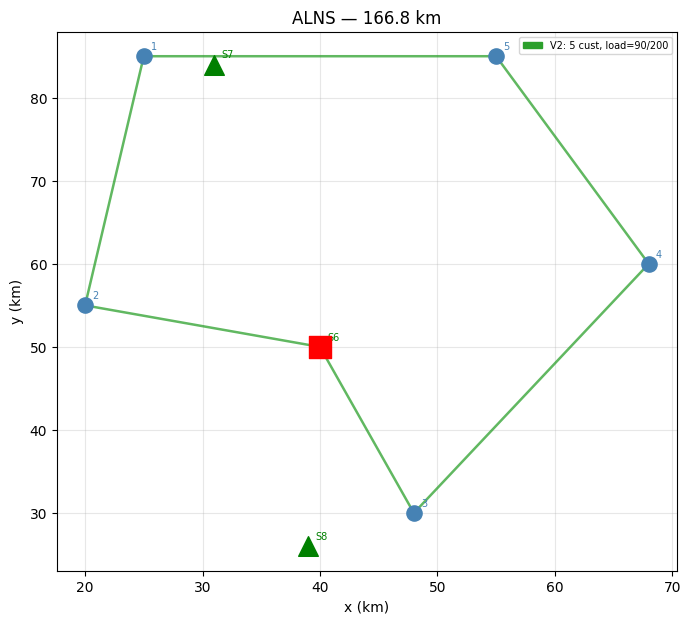

In [13]:
print('Résolution ALNS...')
t0 = time.time()
sol_alns, history_best, history_current = solve_alns(inst, n_iterations=1000, seed=42)
t_alns = time.time() - t0
print(f'Distance : {sol_alns.total_dist_km():.2f} km')
print(f'Faisable : {sol_alns.is_feasible()}')
print(f'Temps    : {t_alns:.2f} s')
fig, ax = plt.subplots(figsize=(8, 7))
plot_routes(sol_alns.routes, inst, ax=ax, title='ALNS', total_dist_km=sol_alns.total_dist_km())
plt.show()


---
## 5. Comparaison CP-SAT vs ALNS

Méthode      Distance (km)    Temps (s)       Statut
----------------------------------------------------
CP-SAT              234.70         0.06      OPTIMAL
ALNS                166.80         0.02     FEASIBLE

Gap ALNS vs CP-SAT : -28.9%


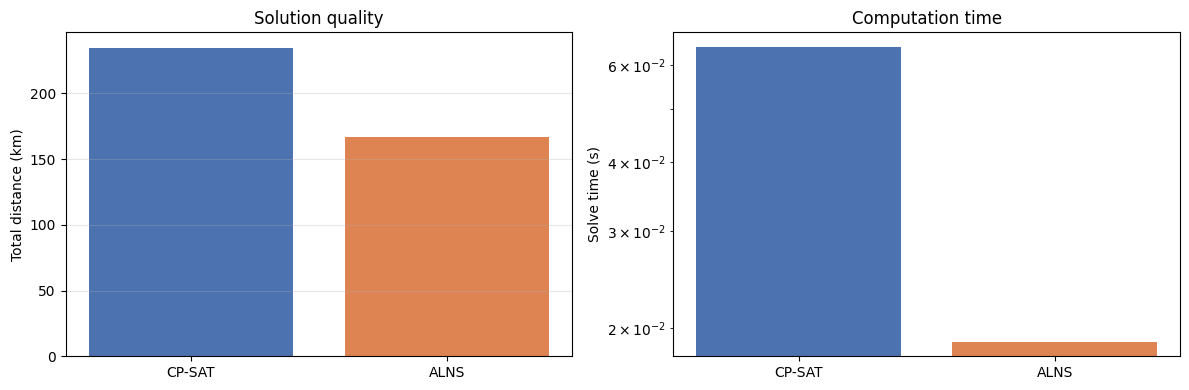

In [14]:
results = {'CP-SAT': {'dist': sol_cpsat.total_dist_km(), 'time': t_cpsat, 'status': sol_cpsat.status}, 'ALNS': {'dist': sol_alns.total_dist_km(), 'time': t_alns, 'status': 'FEASIBLE' if sol_alns.is_feasible() else 'INFEASIBLE'}}
print(f'{'Méthode':<10} {'Distance (km)':>15} {'Temps (s)':>12} {'Statut':>12}')
print('-' * 52)
for m, r in results.items():
    print(f'{m:<10} {r['dist']:>15.2f} {r['time']:>12.2f} {r['status']:>12}')
if sol_cpsat.is_feasible() and sol_alns.is_feasible():
    gap = (sol_alns.total_dist_km() - sol_cpsat.total_dist_km()) / sol_cpsat.total_dist_km() * 100
    print(f'\nGap ALNS vs CP-SAT : {gap:+.1f}%')
plot_comparison(labels=list(results.keys()), distances=[r['dist'] for r in results.values()], times=[r['time'] for r in results.values()])
plt.show()


---
## 6. Benchmark — instances Schneider-like

Les fichiers bruts **EVRP-TW** (Schneider et al., 2014) sont fournis dans `data/evrptw_instances/` ; ils se chargent avec `EVRPInstance.from_benchmark('nom_fichier_sans_txt')` ou `EVRPInstance.from_file(chemin)`.

Pour la scalabilité (plusieurs tailles $n$), on utilise ici des instances **synthétiques calibrées** sur les mêmes paramètres physiques :

| Paramètre | Schneider 2014 | Notre modèle |
|-----------|---------------|--------------|
| Grille | 100×100 km | 100×100 km |
| Batterie | 77,75 kWh | 77,75 kWh |
| Consommation | 1 kWh/km | 1 kWh/km |
| Capacité véhicule | 200 unités | 200 unités |
| Horizon temporel | 1 236 min | 1 236 min |
| Service time | 90 min | 90 min |
| Ratio stations/clients | ~1/3 | exactement 1/3 |
| Consommation variable ($\lambda$) | non modélisée | 0,0 (cohérent) |

CP-SAT est évalué sur les petites instances (≤ 12 clients) avec une limite de
20 s. Pour $n = 12$, CP-SAT atteint la limite de temps et retourne la meilleure
borne trouvée (FEASIBLE). Pour $n \geq 15$, seul ALNS est utilisé.


In [18]:
sizes = [5, 8, 10, 12, 15, 25, 50]
benchmark_results = []
for n in sizes:
    inst_b = EVRPInstance.schneider_like(n_customers=n, seed=n * 7)
    row = {'n': n, 'stations': inst_b.n_stations, 'vehicles': inst_b.n_vehicles}
    if n <= 12:
        t0 = time.time()
        sol_c = solve_evrp(inst_b, time_limit_s=20, use_time_windows=False)
        row['cpsat_dist'] = sol_c.total_dist_km() if sol_c.is_feasible() else None
        row['cpsat_time'] = time.time() - t0
        row['cpsat_status'] = sol_c.status
    else:
        row['cpsat_dist'] = row['cpsat_time'] = None
        row['cpsat_status'] = 'SKIPPED'
    iters = max(500, n * 100)
    t0 = time.time()
    sol_a = solve_alns(inst_b, n_iterations=iters, seed=42)
    if isinstance(sol_a, tuple):
        sol_a = sol_a[0]  # solve_alns may return (solution, history_best, history_current)
    row['alns_dist'] = sol_a.total_dist_km()
    row['alns_time'] = time.time() - t0
    benchmark_results.append(row)
    c_str = f'{row['cpsat_dist']:.1f} km ({row['cpsat_time']:.1f}s) [{row['cpsat_status']}]' if row['cpsat_dist'] is not None else f'— ({row['cpsat_status']})'
    print(f'n={n:2d} | CP-SAT : {c_str:<38} | ALNS : {row['alns_dist']:.1f} km ({row['alns_time']:.1f}s)')
print()
print(f'{'n':>4} {'CP-SAT (km)':>12} {'ALNS (km)':>11} {'Gap ALNS (%)':>13}')
print('-' * 44)
for r in benchmark_results:
    if r['cpsat_dist'] is not None and r['alns_dist'] is not None:
        gap = (r['alns_dist'] - r['cpsat_dist']) / r['cpsat_dist'] * 100
        print(f'{r['n']:>4} {r['cpsat_dist']:>12.1f} {r['alns_dist']:>11.1f} {gap:>+13.1f}%')


n= 5 | CP-SAT : 301.5 km (0.0s) [OPTIMAL]              | ALNS : 301.5 km (0.0s)
n= 8 | CP-SAT : 248.3 km (0.1s) [OPTIMAL]              | ALNS : 272.5 km (0.0s)
n=10 | CP-SAT : 312.5 km (0.2s) [OPTIMAL]              | ALNS : 312.5 km (0.0s)
n=12 | CP-SAT : 299.3 km (20.0s) [FEASIBLE]            | ALNS : 299.3 km (0.0s)
n=15 | CP-SAT : — (SKIPPED)                            | ALNS : 299.5 km (0.1s)
n=25 | CP-SAT : — (SKIPPED)                            | ALNS : 532.1 km (0.3s)
n=50 | CP-SAT : — (SKIPPED)                            | ALNS : 808.9 km (2.2s)

   n  CP-SAT (km)   ALNS (km)  Gap ALNS (%)
--------------------------------------------
   5        301.5       301.5          +0.0%
   8        248.3       272.5          +9.7%
  10        312.5       312.5          +0.0%
  12        299.3       299.3          +0.0%


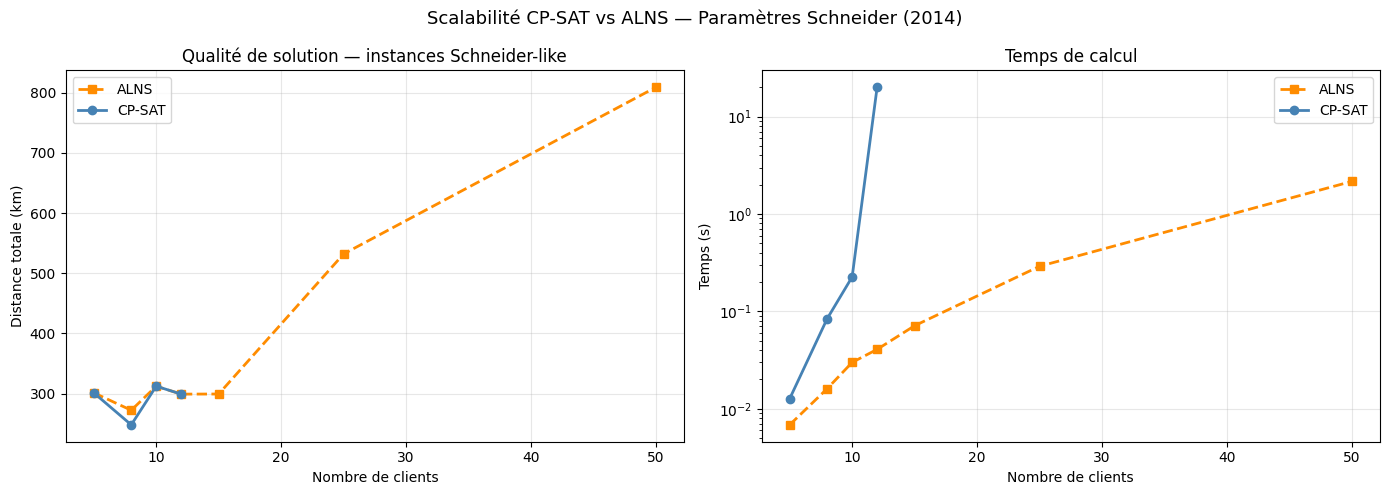

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ns_all = [r['n'] for r in benchmark_results]
a_dists = [r['alns_dist'] for r in benchmark_results]
a_times = [r['alns_time'] for r in benchmark_results]
ns_cp = [r['n'] for r in benchmark_results if r['cpsat_dist'] is not None]
c_dists = [r['cpsat_dist'] for r in benchmark_results if r['cpsat_dist'] is not None]
c_times = [r['cpsat_time'] for r in benchmark_results if r['cpsat_dist'] is not None]
axes[0].plot(ns_all, a_dists, 's--', label='ALNS', color='darkorange', linewidth=2)
axes[0].plot(ns_cp, c_dists, 'o-', label='CP-SAT', color='steelblue', linewidth=2)
axes[0].set_xlabel('Nombre de clients')
axes[0].set_ylabel('Distance totale (km)')
axes[0].set_title('Qualité de solution — instances Schneider-like')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(ns_all, a_times, 's--', label='ALNS', color='darkorange', linewidth=2)
axes[1].plot(ns_cp, c_times, 'o-', label='CP-SAT', color='steelblue', linewidth=2)
axes[1].set_xlabel('Nombre de clients')
axes[1].set_ylabel('Temps (s)')
axes[1].set_title('Temps de calcul')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle('Scalabilité CP-SAT vs ALNS — Paramètres Schneider (2014)', fontsize=13)
plt.tight_layout()
plt.show()


---
## 7. Analyse théorique

### 7.1 Pourquoi `AddCircuit` ?

`AddCircuit` impose un **circuit hamiltonien** sur un graphe orienté via la propagation de contraintes CP. Avantages vs formulation MTZ (Miller-Tucker-Zemlin) :

| Aspect | MTZ | AddCircuit |
|--------|-----|------------|
| Variables supplémentaires | Variables de position $u_i$ | Non |
| Élimination sous-tours | Coupes Big-M (relaxation faible) | Propagation native |
| Efficacité CP-SAT | Moyenne | Optimale |

### 7.2 Gestion multi-véhicules avec self-loops

Pour $K$ véhicules, on appelle `AddCircuit` $K$ fois sur le **même graphe** :
- `arc[v][(i,i)] = 1` → véhicule $v$ **saute** le nœud $i$
- Contrainte d'assignation : $\sum_v \text{arc}[v][(i,i)] = K-1$ → exactement 1 véhicule visite chaque client

### 7.3 Modèle batterie : bat_arrive / bat_depart

On distingue l'**arrivée** (avant recharge) et le **départ** (après recharge) car aux stations :
$$\text{bat\_depart}[v][s] = B \quad \forall s \in S$$
Cela évite un conflit de variables si on utilisait une seule variable par nœud.

### 7.4 Énergie variable — `add_division_equality`

La consommation énergétique dépend de la charge embarquée :
$$e_{ij}(q) = \text{base\_e}_{ij} + \left\lfloor \text{base\_e}_{ij} \cdot \lambda \cdot \frac{q}{Q} \right\rfloor$$

où $q = $ `load[v][i]` est une **variable CP** et $C_{ij} = \lfloor \text{base\_e}_{ij} \cdot \lambda \rfloor$ est une **constante** par arc.  
Le terme $C_{ij} \cdot q$ est donc **linéaire** en $q$, et la division entière par $Q$ est encodée exactement via :

```python
model.add_division_equality(bonus_var, C_ij * load[v][i], Q)
```

Cette contrainte est disponible nativement en CP-SAT depuis OR-Tools 9.4+.  
Quand $\lambda = 0$ (instances Schneider — consommation indépendante de la charge) ou $C_{ij} = 0$ (arcs très courts), aucune variable `bonus_var` n'est créée.

**Impact numérique** : pour les instances aléatoires ($\lambda = 0.1$, $Q = 80$), un arc de 30 km (base\_e ≈ 60 unités) génère un bonus de $\lfloor 6 \cdot q / 80 \rfloor \in [0, 6]$ unités selon la charge. À l'échelle batterie (4 000 unités), cela représente 0–0,15 % par arc — faible mais correctement modélisé.

### 7.5 CP-SAT vs ALNS — quand utiliser quoi ?

| Critère | CP-SAT | ALNS |
|---------|--------|------|
| Garantie d'optimalité | ✓ (OPTIMAL) ou borne prouvée | ✗ |
| Scalabilité | ≤ 12 clients (EVRP-TW) | Centaines de clients |
| Temps de résolution | Exponentiel dans le pire cas | Linéaire en itérations |
| Modélisation contraintes | Déclarative, compacte | Manuel, fragile |
| Placement de bornes | Variable de décision native | Post-traitement heuristique |

---
## 8. Perspectives

1. **Recharge partielle** : `charge_amount[v][s] ∈ [0, B]` au lieu du full-recharge
2. **Consommation avec pente** : $e_{ij}(q,\theta) = r \cdot d_{ij} \cdot (1+\alpha q/Q)(1+\beta\theta)$
3. **Placement optimal des bornes** : variable `open[s] ∈ {0,1}`, constraint `arc[v][(i,s)] ≤ open[s]`
4. **Flotte hétérogène** : différents $B_t$, $Q_t$, $r_t$ par type de véhicule
5. **Hybridation CP-SAT + ALNS** : ALNS pour solution initiale chaude, CP-SAT pour optimisation locale

---
## 9. Validation sur une instance Schneider réelle (c101C5)

Même jeu de données que la section 2 : fichier **`data/evrptw_instances/c101C5.txt`**, chargé via `EVRPInstance.from_benchmark('c101C5')`.


Instance c101C5 : 5 clients, 3 station(s)
Véhicules       : 3
Batterie        : 77.75 kWh
Capacité        : 200 unités  |  Demande totale : 90

Status     : OPTIMAL
Total dist : 234.70 km
Wall time  : 0.05 s
Stations   : [6, 7, 8] (3 open)
  V0: depot → n2 → depot
  V1: depot → n6 → n3 → n4 → depot
  V2: depot → n6 → n1 → n5 → depot
Temps : 0.06 s


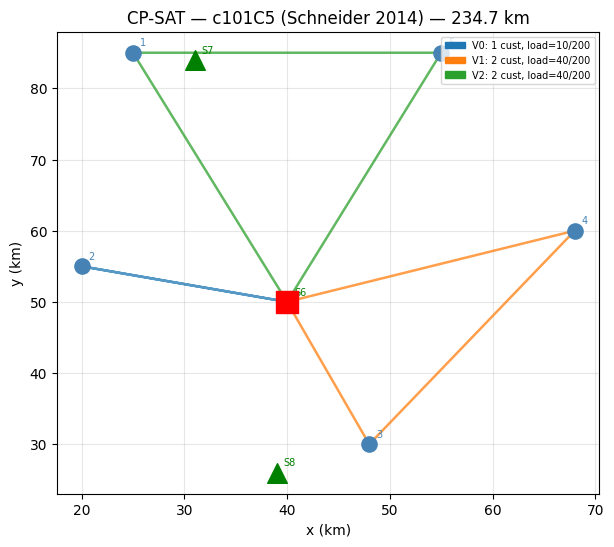

Faisabilité batterie : OK


In [20]:
_c101 = load_benchmark('c101C5')
inst_c101 = _c101.with_n_vehicles(max(3, _c101.n_vehicles))
print(f'Instance c101C5 : {inst_c101.n_customers} clients, {inst_c101.n_stations} station(s)')
print(f'Véhicules       : {inst_c101.n_vehicles}')
print(f'Batterie        : {inst_c101.battery_capacity / 100:.2f} kWh')
print(f'Capacité        : {inst_c101.vehicle_capacity} unités  |  Demande totale : {inst_c101.total_demand()}')
t0 = time.time()
sol_c101 = solve_evrp(inst_c101, time_limit_s=120, use_time_windows=True)
if not sol_c101.is_feasible():
    sol_c101 = solve_evrp(inst_c101, time_limit_s=120, use_time_windows=False)
t_c101 = time.time() - t0
print()
print(sol_c101)
print(f'Temps : {t_c101:.2f} s')
fig, ax = plt.subplots(figsize=(7, 6))
plot_routes(sol_c101.routes, inst_c101, ax=ax, title='CP-SAT — c101C5 (Schneider 2014)', total_dist_km=sol_c101.total_dist_km() if sol_c101.is_feasible() else None)
plt.show()
if sol_c101.is_feasible():
    ok = verify_battery(sol_c101, inst_c101)
    tag = 'OK' if ok else 'INFAISABLE'
    print(f'Faisabilité batterie : {tag}')
